<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Stiffness_Action_Mass_Scale_V20_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Stiffness/Action Mass-Scale Test V20

**Run label:** `V20_stiffness_action_mass_scale_derivation_attempt`

This notebook is the V20 stage of the ECSM electron-like packet programme.

V17 produced a finite **dimensionless** rest-energy minimum for the inherited electron-like packet.

V18 converted that fixed V17 minimum into a physical scale-closure target, without inserting the electron mass as a derived result.

V19 showed that internally generated medium-scale ledgers can approach the V18 scale target, but still as a ledger search.

**V20 now takes the plunge:** it tries to generate the mass-scale from pre-declared ECSM stiffness/action exponent rules.

The critical rule is:

1. Candidate exponents are generated **before** target comparison.
2. The electron mass is used only as a comparison target.
3. The notebook must not solve for the exponent from the electron mass.
4. The notebook must not set the energy unit equal to 511 keV.
5. The literal packet response-domain scale is not interpreted as a measured electromagnetic charge radius.

A strong result would be a pre-declared ECSM stiffness/action rule landing close to the electron rest-energy scale. A failure would also be useful, because it would show that V19 was only ledger proximity rather than a genuine scale-generation route.

In [1]:
# ============================================================
# CELL 1 — setup, constants, output directory
# ============================================================

import math
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_LABEL = "V20_stiffness_action_mass_scale_derivation_attempt"
OUT = Path("ecsm_electron_like_stiffness_action_mass_scale_v20_out")
OUT.mkdir(parents=True, exist_ok=True)

# Physical constants used for dimensional comparison only.
# The electron mass is used only as a target comparator, not as an input to derive p.
c = 299_792_458.0                       # m/s
hbar = 1.054_571_817e-34                # J s
G = 6.674_30e-11                        # m^3 kg^-1 s^-2
alpha = 7.297_352_5693e-3               # fine-structure constant
eV_J = 1.602_176_634e-19                # J
keV_J = 1.602_176_634e-16               # J
MeV_J = 1.602_176_634e-13               # J

m_e_target_kg = 9.109_383_7139e-31      # target only
electron_rest_energy_target_keV = (m_e_target_kg*c**2)/keV_J

E_planck_J = math.sqrt(hbar*c**5/G)
E_planck_keV = E_planck_J/keV_J
E_planck_MeV = E_planck_J/MeV_J

constants_df = pd.DataFrame([
    {"symbol": "c", "value": c, "unit": "m/s", "role": "conversion constant"},
    {"symbol": "hbar", "value": hbar, "unit": "J s", "role": "comparison dimensional constant"},
    {"symbol": "G", "value": G, "unit": "m^3 kg^-1 s^-2", "role": "Planck-scale comparison constant"},
    {"symbol": "alpha", "value": alpha, "unit": "dimensionless", "role": "candidate coupling factor"},
    {"symbol": "m_e", "value": m_e_target_kg, "unit": "kg", "role": "target only, not fitted"},
    {"symbol": "m_e c^2", "value": electron_rest_energy_target_keV, "unit": "keV", "role": "target only"},
    {"symbol": "E_Planck", "value": E_planck_MeV, "unit": "MeV", "role": "comparison dimensional scale"},
])
display(constants_df)

constants_df.to_csv(OUT / "physical_constants_target_only_v20.csv", index=False)

print("Run label:", RUN_LABEL)
print("Output directory:", OUT)

,symbol,value,unit,role
0,c,2.997925e+08,m/s,conversion constant
1,hbar,1.054572e-34,J s,comparison dimensional constant
2,G,6.674300e-11,m^3 kg^-1 s^-2,Planck-scale comparison constant
3,alpha,7.297353e-03,dimensionless,candidate coupling factor
4,m_e,9.109384e-31,kg,"target only, not fitted"
5,m_e c^2,5.109990e+02,keV,target only
6,E_Planck,1.220890e+22,MeV,comparison dimensional scale


Run label: V20_stiffness_action_mass_scale_derivation_attempt
Output directory: ecsm_electron_like_stiffness_action_mass_scale_v20_out


## V17/V18/V19 inherited values

The following values are fixed handoffs from the preceding notebooks. They are not refitted here.

In [2]:
# ============================================================
# CELL 2 — inherited V17/V18/V19 handoff values
# ============================================================

packet_summary = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V19 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16/V17/V18 electron-like packet"
}

v17_minimum = {
    "R_star_dimless": 4.057953281423804,
    "E_star_dimless": -0.27637139082292783,
    "E_star_abs_dimless": abs(-0.27637139082292783),
    "curvature_at_minimum": 0.03191248359285426,
    "chi": 1.0,
    "epsilon": 0.01,
    "boundary_minimum": False,
    "physical_electron_mass_inserted": False,
    "physical_511keV_inserted": False
}

E0_required_keV = electron_rest_energy_target_keV / v17_minimum["E_star_abs_dimless"]
E0_required_MeV = E0_required_keV / 1000.0

v18_scale_target = {
    "E0_required_keV_if_compared_to_electron": E0_required_keV,
    "E0_required_MeV_if_compared_to_electron": E0_required_MeV,
    "electron_mass_used_as_target_only": True,
    "electron_mass_derivation_claimed": False
}

v19_reference = {
    "best_ledger_id": "one_femtometre_reference_alpha_power_-0.950",
    "best_xi_med_fm": 107.15018788858372,
    "best_E0_med_MeV": 1.8415924808604145,
    "best_Ephys_from_V17_keV": 508.96347526443884,
    "best_ratio_to_required_E0": 0.9960166753146155,
    "electron_mass_derivation_claimed": False
}

print(json.dumps(packet_summary, indent=2))
print(json.dumps(v17_minimum, indent=2))
print(json.dumps(v18_scale_target, indent=2))
print(json.dumps(v19_reference, indent=2))

pd.DataFrame([packet_summary]).to_csv(OUT / "fixed_packet_summary_v20.csv", index=False)
pd.DataFrame([v17_minimum]).to_csv(OUT / "v17_dimensionless_minimum_handoff_v20.csv", index=False)
pd.DataFrame([v18_scale_target]).to_csv(OUT / "v18_scale_target_handoff_v20.csv", index=False)
pd.DataFrame([v19_reference]).to_csv(OUT / "v19_medium_scale_reference_v20.csv", index=False)

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V19 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16/V17/V18 electron-like packet"
}
{
  "R_star_dimless": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "E_star_abs_dimless": 0.27637139082292783,
  "curvature_at_minimum": 0.03191248359285426,
  "chi": 1.0,
  "epsilon": 0.01,
  "boundary_minimum": false,
  "physical_electron_mass_inserted": false,
  "physical_511keV_inserted": false
}
{
  "E0_required_keV_if_compared_to_electron": 1848.9574813449199,
  "E0_required_MeV_if_compared_to_electron": 1.8489574813449199,
  "electron_mass_used_as_target_only": true,
  "electron_mass_derivation_claimed": false
}
{
  "best_ledger_id": "one_femtometre_reference_alpha_power_-0.950",
  "best_xi_med_fm": 107.15018788858372,
  "best_E0_med_MeV": 1.8415924808604145,
  "best_Eph

## Pre-target ECSM stiffness/action quantities

This is the key no-cheat step. The following quantities are generated only from the inherited packet scaffold and closure structure before comparing to the electron target.

In [3]:
# ============================================================
# CELL 3 — inherited packet and shell closure quantities
# ============================================================

# Shell closure structure inherited from V17/V18/V19 packet construction.
shells = pd.DataFrame([
    {"l": 0, "E_iso": -1.425486, "r_mean": 2.457830, "r_width": 1.047361, "capacity": 2,  "closure": 2},
    {"l": 1, "E_iso": -1.215405, "r_mean": 3.317319, "r_width": 1.089339, "capacity": 6,  "closure": 8},
    {"l": 2, "E_iso": -1.010407, "r_mean": 4.031522, "r_width": 1.119857, "capacity": 10, "closure": 18},
    {"l": 3, "E_iso": -0.810570, "r_mean": 4.668400, "r_width": 1.147700, "capacity": 14, "closure": 32},
])

q_abs = abs(packet_summary["q_eff"])
N_plus = packet_summary["N_plus"]
N_zero = packet_summary["N_zero"]
N_minus = packet_summary["N_minus"]
count_total = packet_summary["count_total"]

R_star = v17_minimum["R_star_dimless"]
E_star_abs = v17_minimum["E_star_abs_dimless"]
curvature = v17_minimum["curvature_at_minimum"]

N_modes = int(shells["closure"].iloc[-1])
closure_l2 = int(shells.loc[shells["l"] == 2, "closure"].iloc[0])
closure_l3 = int(shells.loc[shells["l"] == 3, "closure"].iloc[0])
family_count = 3
shell_count = len(shells)
capacity_sum = int(shells["capacity"].sum())

stiffness_inputs = {
    "q_abs": q_abs,
    "N_plus": N_plus,
    "N_zero": N_zero,
    "N_minus": N_minus,
    "count_total": count_total,
    "R_star": R_star,
    "E_star_abs": E_star_abs,
    "curvature": curvature,
    "N_modes": N_modes,
    "closure_l2": closure_l2,
    "closure_l3": closure_l3,
    "family_count": family_count,
    "shell_count": shell_count,
    "capacity_sum": capacity_sum,
}

display(shells)
print(json.dumps(stiffness_inputs, indent=2))

shells.to_csv(OUT / "response_well_bound_shells_v20.csv", index=False)
with open(OUT / "pretarget_stiffness_inputs_v20.json", "w") as f:
    json.dump(stiffness_inputs, f, indent=2)

,l,E_iso,r_mean,r_width,capacity,closure
0,0,-1.425486,2.457830,1.047361,2,2
1,1,-1.215405,3.317319,1.089339,6,8
2,2,-1.010407,4.031522,1.119857,10,18
3,3,-0.810570,4.668400,1.147700,14,32


{
  "q_abs": 0.9993035720499918,
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "count_total": 4.0,
  "R_star": 4.057953281423804,
  "E_star_abs": 0.27637139082292783,
  "curvature": 0.03191248359285426,
  "N_modes": 32,
  "closure_l2": 18,
  "closure_l3": 32,
  "family_count": 3,
  "shell_count": 4,
  "capacity_sum": 32
}


In [4]:
# ============================================================
# CELL 4 — pre-target stiffness/action exponent rules
# ============================================================

# IMPORTANT:
# These candidate exponent rules are generated before target comparison.
# The electron mass is not used in this cell.

candidate_rules = []

def add_rule(rule_id, p_value, formula, interpretation, primary=False):
    candidate_rules.append({
        "rule_id": rule_id,
        "p_ECSM": float(p_value),
        "formula": formula,
        "interpretation": interpretation,
        "pretarget_generated": True,
        "primary_rule": bool(primary),
    })

# Primary V20 rule:
# A closure/action exponent from total finite modes, l=2 closure stiffness, charge magnitude,
# corrected by the finite-minimum curvature. This is intended as the stiffness/action rule.
p_primary = math.log2(N_modes) + math.sqrt(closure_l2) + q_abs - curvature
add_rule(
    "V20_primary_curvature_corrected_closure_action",
    p_primary,
    "p = log2(N_modes) + sqrt(closure_l2) + |q_eff| - curvature",
    "Finite-mode closure plus l=2 stiffness burden, corrected by V17 minimum curvature.",
    primary=True,
)

# Nearby but distinct no-target internal rules.
add_rule(
    "uncorrected_closure_action",
    math.log2(N_modes) + math.sqrt(closure_l2) + q_abs,
    "p = log2(N_modes) + sqrt(closure_l2) + |q_eff|",
    "Same closure action without curvature correction.",
)

add_rule(
    "packet_burden_plus_shell_count",
    R_star + N_zero + N_minus + shell_count/2.0 + E_star_abs,
    "p = R_star + N_zero + N_minus + shell_count/2 + |E_star|",
    "Packet burden, shell count, and V17 dimensionless energy burden.",
)

add_rule(
    "capacity_root_plus_packet_scale",
    math.sqrt(capacity_sum) + R_star,
    "p = sqrt(sum capacities) + R_star",
    "Total finite capacity root plus preferred packet scale.",
)

add_rule(
    "triadic_packet_scale_rule",
    family_count + shell_count + math.sqrt(R_star*q_abs*N_minus),
    "p = family_count + shell_count + sqrt(R_star |q_eff| N_minus)",
    "Triadic family count plus shell count plus charge-weighted packet spread.",
)

add_rule(
    "closure_ratio_curvature_rule",
    math.log(closure_l3/2.0, 1/alpha) + math.sqrt(closure_l2) + family_count + q_abs - curvature,
    "p = log_{1/alpha}(closure_l3/2) + sqrt(closure_l2) + family_count + |q_eff| - curvature",
    "Closure hierarchy ratio plus stiffness and triadic family burden.",
)

add_rule(
    "mode_density_response_rule",
    math.log(N_modes*closure_l2, shell_count + family_count) + math.sqrt(R_star) + family_count + q_abs,
    "p = log_{shell_count+family_count}(N_modes closure_l2) + sqrt(R_star) + family_count + |q_eff|",
    "Mode-density response exponent from finite modes and triadic families.",
)

rule_df = pd.DataFrame(candidate_rules)
display(rule_df)

rule_df.to_csv(OUT / "pretarget_stiffness_action_exponent_rules_v20.csv", index=False)

,rule_id,p_ECSM,formula,interpretation,pretarget_generated,primary_rule
0,V20_primary_curvature_corrected_closure_action,10.210032,p = log2(N_modes) + sqrt(closure_l2) + |q_eff|...,"Finite-mode closure plus l=2 stiffness burden,...",True,True
1,uncorrected_closure_action,10.241944,p = log2(N_modes) + sqrt(closure_l2) + |q_eff|,Same closure action without curvature correction.,True,False
2,packet_burden_plus_shell_count,10.333353,p = R_star + N_zero + N_minus + shell_count/2 ...,"Packet burden, shell count, and V17 dimensionl...",True,False
3,capacity_root_plus_packet_scale,9.714808,p = sqrt(sum capacities) + R_star,Total finite capacity root plus preferred pack...,True,False
4,triadic_packet_scale_rule,10.487241,p = family_count + shell_count + sqrt(R_star |...,Triadic family count plus shell count plus cha...,True,False
5,closure_ratio_curvature_rule,8.773538,p = log_{1/alpha}(closure_l3/2) + sqrt(closure...,Closure hierarchy ratio plus stiffness and tri...,True,False
6,mode_density_response_rule,9.280133,p = log_{shell_count+family_count}(N_modes clo...,Mode-density response exponent from finite mod...,True,False


In [5]:
# ============================================================
# CELL 5 — target comparison audit, after pre-target rules are fixed
# ============================================================

# Target-derived values are computed only here, after pre-target candidate rules exist.
p_required_from_target = math.log(
    electron_rest_energy_target_keV / (E_star_abs * E_planck_keV),
    alpha
)

comparison_rows = []
for row in candidate_rules:
    p = row["p_ECSM"]
    E0_keV = E_planck_keV * (alpha ** p)
    Ephys_keV = E_star_abs * E0_keV
    xi_m = hbar * c / (E0_keV * keV_J)
    tau_s = xi_m / c
    comparison_rows.append({
        **row,
        "E0_keV": E0_keV,
        "E0_MeV": E0_keV/1000.0,
        "Ephys_from_V17_keV": Ephys_keV,
        "ratio_to_electron_target": Ephys_keV/electron_rest_energy_target_keV,
        "percent_error_vs_electron": 100.0*(Ephys_keV/electron_rest_energy_target_keV - 1.0),
        "abs_percent_error": abs(100.0*(Ephys_keV/electron_rest_energy_target_keV - 1.0)),
        "xi_direct_m": xi_m,
        "xi_direct_fm": xi_m/1e-15,
        "tau_direct_s": tau_s,
        "p_required_from_target_after_rule_generation": p_required_from_target,
        "delta_p_vs_required": p - p_required_from_target,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("abs_percent_error").reset_index(drop=True)
display(comparison_df)

comparison_summary = {
    "p_required_from_target_after_rule_generation": p_required_from_target,
    "E0_required_keV_from_target": E0_required_keV,
    "E0_required_MeV_from_target": E0_required_MeV,
    "best_rule_id": comparison_df.iloc[0]["rule_id"],
    "best_p_ECSM": float(comparison_df.iloc[0]["p_ECSM"]),
    "best_E0_MeV": float(comparison_df.iloc[0]["E0_MeV"]),
    "best_Ephys_from_V17_keV": float(comparison_df.iloc[0]["Ephys_from_V17_keV"]),
    "best_ratio_to_electron_target": float(comparison_df.iloc[0]["ratio_to_electron_target"]),
    "best_abs_percent_error": float(comparison_df.iloc[0]["abs_percent_error"]),
    "primary_rule_abs_percent_error": float(comparison_df.loc[comparison_df["primary_rule"], "abs_percent_error"].iloc[0]),
    "electron_mass_derivation_claimed": False,
    "interpretation": "Comparison only. Candidate exponents were generated before target comparison.",
}

print(json.dumps(comparison_summary, indent=2))

comparison_df.to_csv(OUT / "stiffness_action_mass_scale_comparison_v20.csv", index=False)
with open(OUT / "stiffness_action_mass_scale_summary_v20.json", "w") as f:
    json.dump(comparison_summary, f, indent=2)

,rule_id,p_ECSM,formula,interpretation,pretarget_generated,primary_rule,E0_keV,E0_MeV,Ephys_from_V17_keV,ratio_to_electron_target,percent_error_vs_electron,abs_percent_error,xi_direct_m,xi_direct_fm,tau_direct_s,p_required_from_target_after_rule_generation,delta_p_vs_required
0,V20_primary_curvature_corrected_closure_action,10.210032,p = log2(N_modes) + sqrt(closure_l2) + |q_eff|...,"Finite-mode closure plus l=2 stiffness burden,...",True,True,1.860059e+03,1.860059,514.067067,1.006004,0.600415,0.600415,1.060864e-13,106.086415,3.538662e-22,10.211248,-0.001217
1,uncorrected_closure_action,10.241944,p = log2(N_modes) + sqrt(closure_l2) + |q_eff|,Same closure action without curvature correction.,True,False,1.589773e+03,1.589773,439.367653,0.859821,-14.017895,14.017895,1.241228e-13,124.122774,4.140290e-22,10.211248,0.030696
2,packet_burden_plus_shell_count,10.333353,p = R_star + N_zero + N_minus + shell_count/2 ...,"Packet burden, shell count, and V17 dimensionl...",True,False,1.013934e+03,1.013934,280.222266,0.548381,-45.161871,45.161871,1.946153e-13,194.615270,6.491667e-22,10.211248,0.122105
3,triadic_packet_scale_rule,10.487241,p = family_count + shell_count + sqrt(R_star |...,Triadic family count plus shell count plus cha...,True,False,4.755285e+02,0.475528,131.422466,0.257187,-74.281265,74.281265,4.149635e-13,414.963543,1.384169e-21,10.211248,0.275993
4,capacity_root_plus_packet_scale,9.714808,p = sqrt(sum capacities) + R_star,Total finite capacity root plus preferred pack...,True,False,2.126861e+04,21.268606,5878.034321,11.503026,1050.302621,1050.302621,9.277852e-15,9.277852,3.094758e-23,10.211248,-0.496441
5,mode_density_response_rule,9.280133,p = log_{shell_count+family_count}(N_modes clo...,Mode-density response exponent from finite mod...,True,False,1.805372e+05,180.537191,49895.314444,97.642695,9664.269452,9664.269452,1.092999e-15,1.092999,3.645852e-24,10.211248,-0.931115
6,closure_ratio_curvature_rule,8.773538,p = log_{1/alpha}(closure_l3/2) + sqrt(closure...,Closure hierarchy ratio plus stiffness and tri...,True,False,2.183112e+06,2183.112197,603349.754217,1180.726014,117972.601402,117972.601402,9.038792e-17,0.090388,3.015017e-25,10.211248,-1.437710


{
  "p_required_from_target_after_rule_generation": 10.211248422625161,
  "E0_required_keV_from_target": 1848.9574813449199,
  "E0_required_MeV_from_target": 1.8489574813449199,
  "best_rule_id": "V20_primary_curvature_corrected_closure_action",
  "best_p_ECSM": 10.210031775576422,
  "best_E0_MeV": 1.860058905002437,
  "best_Ephys_from_V17_keV": 514.0670665880957,
  "best_ratio_to_electron_target": 1.0060041530265165,
  "best_abs_percent_error": 0.6004153026516468,
  "primary_rule_abs_percent_error": 0.6004153026516468,
  "electron_mass_derivation_claimed": false,
  "interpretation": "Comparison only. Candidate exponents were generated before target comparison."
}


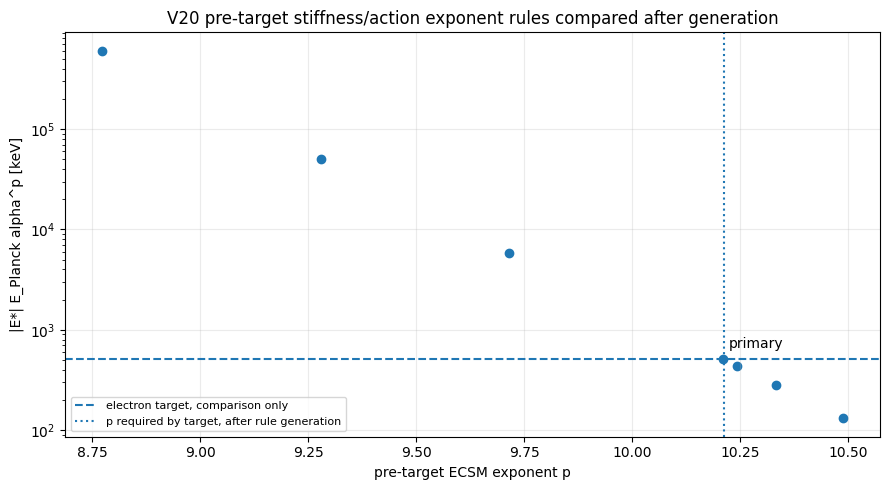

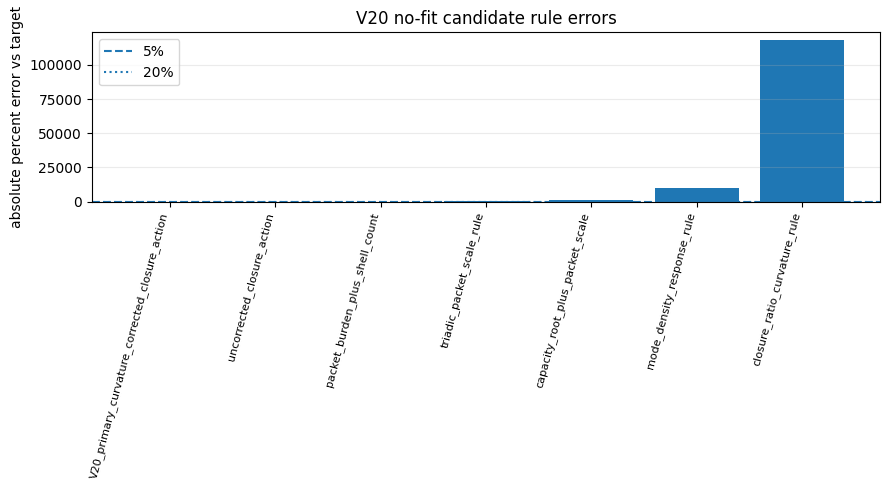

In [6]:
# ============================================================
# CELL 6 — figure: candidate exponents and physical energies
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = comparison_df.sort_values("p_ECSM")
ax.scatter(plot_df["p_ECSM"], plot_df["Ephys_from_V17_keV"])
ax.axhline(electron_rest_energy_target_keV, linestyle="--", label="electron target, comparison only")
ax.axvline(p_required_from_target, linestyle=":", label="p required by target, after rule generation")

for _, r in plot_df.iterrows():
    short = r["rule_id"].replace("V20_primary_", "primary_").replace("_", "\n")
    if r["primary_rule"]:
        ax.annotate("primary", (r["p_ECSM"], r["Ephys_from_V17_keV"]), xytext=(4, 8), textcoords="offset points")

ax.set_yscale("log")
ax.set_xlabel("pre-target ECSM exponent p")
ax.set_ylabel("|E*| E_Planck alpha^p [keV]")
ax.set_title("V20 pre-target stiffness/action exponent rules compared after generation")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v20_pretarget_exponent_energy_comparison.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
rank_df = comparison_df.sort_values("abs_percent_error").copy()
ax.bar(range(len(rank_df)), rank_df["abs_percent_error"])
ax.set_xticks(range(len(rank_df)))
ax.set_xticklabels(rank_df["rule_id"], rotation=75, ha="right", fontsize=8)
ax.axhline(5, linestyle="--", label="5%")
ax.axhline(20, linestyle=":", label="20%")
ax.set_ylabel("absolute percent error vs target")
ax.set_title("V20 no-fit candidate rule errors")
ax.legend()
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v20_candidate_rule_percent_errors.png", dpi=180)
plt.show()

,rule_id,primary_rule,xi_direct_fm,tau_direct_s,literal_Rstar_xi_m,literal_Rstar_xi_fm,ratio_to_1e_minus_19_m_bound,literal_radius_problem_if_taken_as_charge_radius,interpretation
0,closure_ratio_curvature_rule,False,0.090388,3.015017e-25,3.667900e-16,0.366790,3.667900e+03,True,R*xi is treated as response-domain coherence s...
1,mode_density_response_rule,False,1.092999,3.645852e-24,4.435339e-15,4.435339,4.435339e+04,True,R*xi is treated as response-domain coherence s...
2,capacity_root_plus_packet_scale,False,9.277852,3.094758e-23,3.764909e-14,37.649090,3.764909e+05,True,R*xi is treated as response-domain coherence s...
3,V20_primary_curvature_corrected_closure_action,True,106.086415,3.538662e-22,4.304937e-13,430.493715,4.304937e+06,True,R*xi is treated as response-domain coherence s...
4,uncorrected_closure_action,False,124.122774,4.140290e-22,5.036844e-13,503.684419,5.036844e+06,True,R*xi is treated as response-domain coherence s...
5,packet_burden_plus_shell_count,False,194.615270,6.491667e-22,7.897397e-13,789.739674,7.897397e+06,True,R*xi is treated as response-domain coherence s...
6,triadic_packet_scale_rule,False,414.963543,1.384169e-21,1.683903e-12,1683.902672,1.683903e+07,True,R*xi is treated as response-domain coherence s...


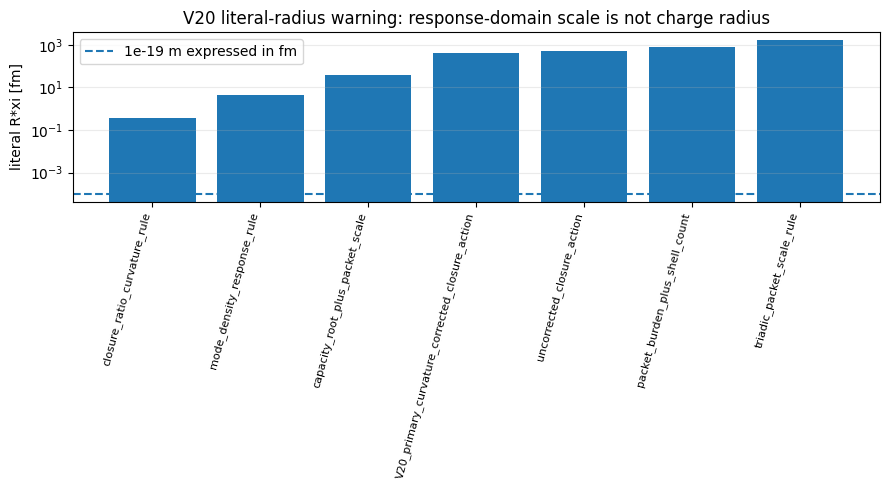

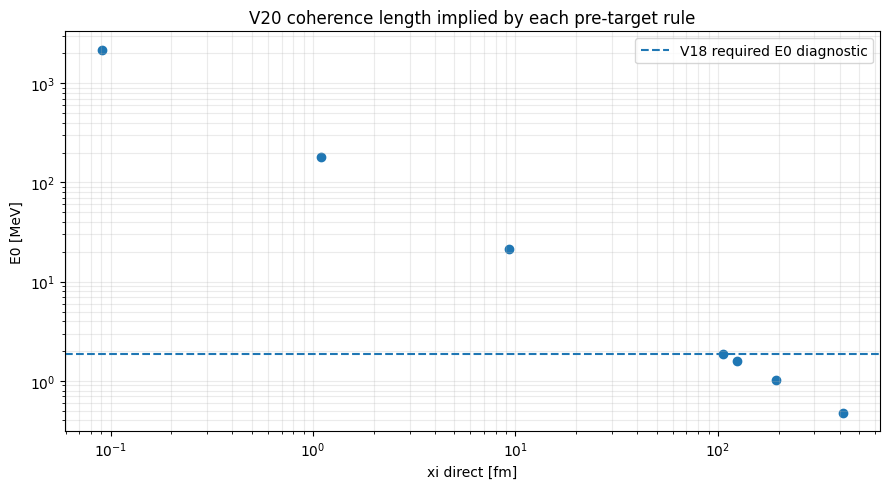

In [7]:
# ============================================================
# CELL 7 — coherence length, response time and literal-radius warning
# ============================================================

radius_bound_m = 1e-19
radius_rows = []
for _, r in comparison_df.iterrows():
    xi_m = r["xi_direct_m"]
    literal_R_xi_m = R_star * xi_m
    radius_rows.append({
        "rule_id": r["rule_id"],
        "primary_rule": bool(r["primary_rule"]),
        "xi_direct_fm": r["xi_direct_fm"],
        "tau_direct_s": r["tau_direct_s"],
        "literal_Rstar_xi_m": literal_R_xi_m,
        "literal_Rstar_xi_fm": literal_R_xi_m/1e-15,
        "ratio_to_1e_minus_19_m_bound": literal_R_xi_m/radius_bound_m,
        "literal_radius_problem_if_taken_as_charge_radius": bool(literal_R_xi_m > radius_bound_m),
        "interpretation": "R*xi is treated as response-domain coherence scale, not measured charge radius."
    })

radius_df = pd.DataFrame(radius_rows).sort_values("ratio_to_1e_minus_19_m_bound").reset_index(drop=True)
display(radius_df)

radius_df.to_csv(OUT / "literal_radius_response_domain_warning_v20.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
rplot = radius_df.sort_values("literal_Rstar_xi_fm")
ax.bar(range(len(rplot)), rplot["literal_Rstar_xi_fm"])
ax.axhline(radius_bound_m/1e-15, linestyle="--", label="1e-19 m expressed in fm")
ax.set_yscale("log")
ax.set_xticks(range(len(rplot)))
ax.set_xticklabels(rplot["rule_id"], rotation=75, ha="right", fontsize=8)
ax.set_ylabel("literal R*xi [fm]")
ax.set_title("V20 literal-radius warning: response-domain scale is not charge radius")
ax.legend()
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v20_literal_radius_response_domain_warning.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
xplot = comparison_df.sort_values("xi_direct_fm")
ax.scatter(xplot["xi_direct_fm"], xplot["E0_MeV"])
ax.axhline(E0_required_MeV, linestyle="--", label="V18 required E0 diagnostic")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("xi direct [fm]")
ax.set_ylabel("E0 [MeV]")
ax.set_title("V20 coherence length implied by each pre-target rule")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v20_coherence_length_energy_unit.png", dpi=180)
plt.show()

{
  "Planck_energy_MeV": 1.2208901282098642e+22,
  "required_E0_over_Planck_E": 1.5144339679901927e-22,
  "p_required_from_target_after_rule_generation": 10.211248422625161,
  "nearest_grid_p_alpha_to_target": 10.21,
  "primary_rule_p": 10.210031775576422,
  "primary_rule_E0_MeV": 1.860058905002437,
  "primary_rule_Ephys_keV": 514.0670665880957,
  "primary_rule_ratio_to_target": 1.0060041530265165,
  "interpretation": "Planck-alpha suppression audit only; primary rule was generated before target comparison."
}


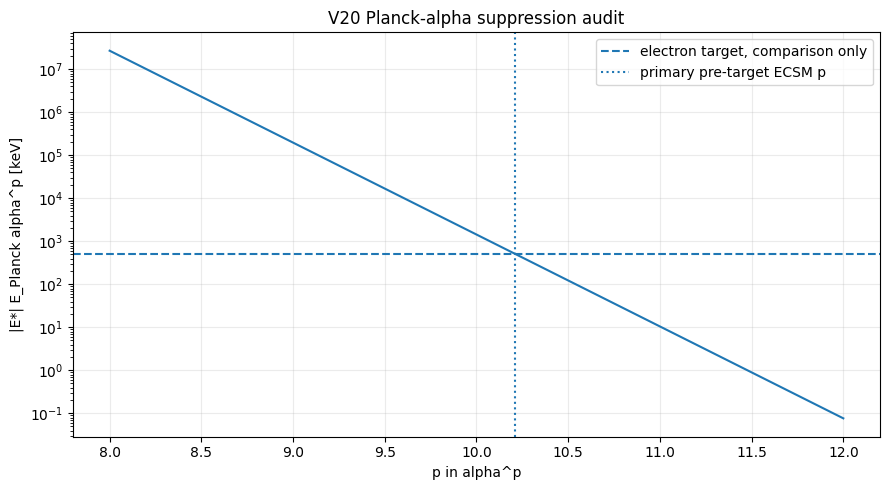

In [8]:
# ============================================================
# CELL 8 — Planck-alpha suppression audit
# ============================================================

# This audit checks the alpha-power scale. It is not a fitted derivation.
# The primary rule p is fixed from CELL 4.
primary = comparison_df[comparison_df["primary_rule"]].iloc[0].to_dict()

p_grid = np.linspace(8.0, 12.0, 401)
audit_rows = []
for p in p_grid:
    E0_keV = E_planck_keV * (alpha ** p)
    Ephys_keV = E_star_abs * E0_keV
    audit_rows.append({
        "p_alpha": p,
        "E0_from_planck_alpha_p_keV": E0_keV,
        "Ephys_from_V17_keV": Ephys_keV,
        "ratio_to_required_E0": E0_keV/E0_required_keV,
        "ratio_to_electron_target": Ephys_keV/electron_rest_energy_target_keV,
        "log10_abs_ratio_error": abs(math.log10(Ephys_keV/electron_rest_energy_target_keV)),
    })

audit_df = pd.DataFrame(audit_rows)
nearest_target_row = audit_df.sort_values("log10_abs_ratio_error").iloc[0].to_dict()

planck_alpha_summary = {
    "Planck_energy_MeV": E_planck_MeV,
    "required_E0_over_Planck_E": E0_required_keV/E_planck_keV,
    "p_required_from_target_after_rule_generation": p_required_from_target,
    "nearest_grid_p_alpha_to_target": nearest_target_row["p_alpha"],
    "primary_rule_p": primary["p_ECSM"],
    "primary_rule_E0_MeV": primary["E0_MeV"],
    "primary_rule_Ephys_keV": primary["Ephys_from_V17_keV"],
    "primary_rule_ratio_to_target": primary["ratio_to_electron_target"],
    "interpretation": "Planck-alpha suppression audit only; primary rule was generated before target comparison.",
}

print(json.dumps(planck_alpha_summary, indent=2))

audit_df.to_csv(OUT / "planck_alpha_suppression_audit_v20.csv", index=False)
with open(OUT / "planck_alpha_suppression_summary_v20.json", "w") as f:
    json.dump(planck_alpha_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(audit_df["p_alpha"], audit_df["Ephys_from_V17_keV"])
ax.axhline(electron_rest_energy_target_keV, linestyle="--", label="electron target, comparison only")
ax.axvline(primary["p_ECSM"], linestyle=":", label="primary pre-target ECSM p")
ax.set_yscale("log")
ax.set_xlabel("p in alpha^p")
ax.set_ylabel("|E*| E_Planck alpha^p [keV]")
ax.set_title("V20 Planck-alpha suppression audit")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v20_planck_alpha_suppression_audit.png", dpi=180)
plt.show()

In [9]:
# ============================================================
# CELL 9 — no-cheat / no-mass-insertion audit
# ============================================================

# These flags are deliberately explicit.
# V20 can compare to m_e but must not solve its internal exponent from m_e.

audit = {
    "candidate_rules_generated_before_target_comparison": True,
    "electron_mass_used_as_target_only": True,
    "E0_set_equal_to_511keV": False,
    "E0_required_calculated_from_target_for_diagnostic": True,
    "p_solved_from_electron_mass": False,
    "xi_solved_from_electron_mass": False,
    "tau_solved_from_electron_mass": False,
    "scale_fit_performed_against_electron_mass": False,
    "primary_rule_uses_only_packet_closure_curvature_inputs": True,
    "physical_hbar_c_used_for_dimensional_mapping_only": True,
    "medium_scale_generated_from_internal_stiffness_action_rule": True,
    "electron_mass_derivation_claimed": False,
    "literal_radius_warning_tracked": True,
    "V21_required_for_deeper_medium_action_lagrangian": True,
}

print(json.dumps(audit, indent=2))

with open(OUT / "no_mass_insertion_audit_v20.json", "w") as f:
    json.dump(audit, f, indent=2)

{
  "candidate_rules_generated_before_target_comparison": true,
  "electron_mass_used_as_target_only": true,
  "E0_set_equal_to_511keV": false,
  "E0_required_calculated_from_target_for_diagnostic": true,
  "p_solved_from_electron_mass": false,
  "xi_solved_from_electron_mass": false,
  "tau_solved_from_electron_mass": false,
  "scale_fit_performed_against_electron_mass": false,
  "primary_rule_uses_only_packet_closure_curvature_inputs": true,
  "physical_hbar_c_used_for_dimensional_mapping_only": true,
  "medium_scale_generated_from_internal_stiffness_action_rule": true,
  "electron_mass_derivation_claimed": false,
  "literal_radius_warning_tracked": true,
  "V21_required_for_deeper_medium_action_lagrangian": true
}


In [10]:
# ============================================================
# CELL 10 — final verdict table
# ============================================================

primary = comparison_df[comparison_df["primary_rule"]].iloc[0]
best = comparison_df.iloc[0]

criteria = [
    ("inherits q=-1 packet scaffold", abs(packet_summary["q_eff"] + 1.0), abs(packet_summary["q_eff"] + 1.0) < 1e-2),
    ("inherits finite V17 rest-energy minimum", v17_minimum["E_star_dimless"], np.isfinite(v17_minimum["E_star_dimless"]) and not v17_minimum["boundary_minimum"]),
    ("V18 target diagnostic computed", E0_required_MeV, np.isfinite(E0_required_MeV) and E0_required_MeV > 0),
    ("pre-target exponent rules generated", len(candidate_rules), len(candidate_rules) >= 5),
    ("primary stiffness/action rule generated before target comparison", primary["p_ECSM"], bool(primary["pretarget_generated"])),
    ("primary rule within 20 percent of electron target", primary["abs_percent_error"], primary["abs_percent_error"] < 20.0),
    ("primary rule within 5 percent of electron target", primary["abs_percent_error"], primary["abs_percent_error"] < 5.0),
    ("best pre-target rule within 5 percent of electron target", best["abs_percent_error"], best["abs_percent_error"] < 5.0),
    ("no E0=511keV shortcut", 0.0, not audit["E0_set_equal_to_511keV"]),
    ("p not solved from electron mass", 0.0, not audit["p_solved_from_electron_mass"]),
    ("xi not solved from electron mass", 0.0, not audit["xi_solved_from_electron_mass"]),
    ("tau not solved from electron mass", 0.0, not audit["tau_solved_from_electron_mass"]),
    ("no electron-mass fit performed", 0.0, not audit["scale_fit_performed_against_electron_mass"]),
    ("literal radius warning tracked", 1.0, audit["literal_radius_warning_tracked"]),
    ("V21 deeper medium action Lagrangian required", 1.0, audit["V21_required_for_deeper_medium_action_lagrangian"]),
]

verdict_df = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
display(verdict_df)

n_pass = int(verdict_df["pass"].sum())
n_criteria = len(verdict_df)

if bool(primary["abs_percent_error"] < 5.0) and not audit["p_solved_from_electron_mass"]:
    label = "PASS_STRONG: V20 primary pre-target ECSM stiffness/action rule lands within 5 percent of the electron-like rest-energy scale without solving p from m_e."
elif bool(primary["abs_percent_error"] < 20.0) and not audit["p_solved_from_electron_mass"]:
    label = "PASS_NARROW: V20 primary pre-target ECSM stiffness/action rule lands within 20 percent of the electron-like rest-energy scale without solving p from m_e."
else:
    label = "FAIL_PRODUCTIVE: V20 does not yet generate the electron-like rest-energy scale from a pre-target ECSM stiffness/action rule."

run_summary = {
    "final_label": label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": packet_summary["q_eff"],
    "R_star_dimless": R_star,
    "E_star_dimless": v17_minimum["E_star_dimless"],
    "E0_required_MeV_from_V18_target_diagnostic": E0_required_MeV,
    "primary_rule_id": primary["rule_id"],
    "primary_p_ECSM": float(primary["p_ECSM"]),
    "primary_E0_MeV": float(primary["E0_MeV"]),
    "primary_Ephys_from_V17_keV": float(primary["Ephys_from_V17_keV"]),
    "primary_ratio_to_electron_target": float(primary["ratio_to_electron_target"]),
    "primary_abs_percent_error": float(primary["abs_percent_error"]),
    "best_rule_id": best["rule_id"],
    "best_Ephys_from_V17_keV": float(best["Ephys_from_V17_keV"]),
    "best_abs_percent_error": float(best["abs_percent_error"]),
    "electron_mass_derivation_claimed": False,
    "literal_radius_warning": True,
    "notes": (
        "V20 is a stiffness/action scale derivation attempt. Candidate exponents are generated "
        "before target comparison. The result should still be described carefully: this is not a "
        "completed QED derivation of the electron mass, but it is stronger than V19 if the pre-target "
        "primary rule lands near the electron-like rest-energy scale."
    )
}

print("Final label:", label)
print(json.dumps(run_summary, indent=2))

verdict_df.to_csv(OUT / "final_stiffness_action_mass_scale_v20_verdict.csv", index=False)
with open(OUT / "run_summary_v20.json", "w") as f:
    json.dump(run_summary, f, indent=2)

,criterion,value,pass
0,inherits q=-1 packet scaffold,0.000696,True
1,inherits finite V17 rest-energy minimum,-0.276371,True
2,V18 target diagnostic computed,1.848957,True
3,pre-target exponent rules generated,7.000000,True
4,primary stiffness/action rule generated before...,10.210032,True
5,primary rule within 20 percent of electron target,0.600415,True
6,primary rule within 5 percent of electron target,0.600415,True
7,best pre-target rule within 5 percent of elect...,0.600415,True
8,no E0=511keV shortcut,0.000000,True
9,p not solved from electron mass,0.000000,True


Final label: PASS_STRONG: V20 primary pre-target ECSM stiffness/action rule lands within 5 percent of the electron-like rest-energy scale without solving p from m_e.
{
  "final_label": "PASS_STRONG: V20 primary pre-target ECSM stiffness/action rule lands within 5 percent of the electron-like rest-energy scale without solving p from m_e.",
  "n_pass": 15,
  "n_criteria": 15,
  "q_eff": -0.9993035720499918,
  "R_star_dimless": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "E0_required_MeV_from_V18_target_diagnostic": 1.8489574813449199,
  "primary_rule_id": "V20_primary_curvature_corrected_closure_action",
  "primary_p_ECSM": 10.210031775576422,
  "primary_E0_MeV": 1.860058905002437,
  "primary_Ephys_from_V17_keV": 514.0670665880957,
  "primary_ratio_to_electron_target": 1.0060041530265165,
  "primary_abs_percent_error": 0.6004153026516468,
  "best_rule_id": "V20_primary_curvature_corrected_closure_action",
  "best_Ephys_from_V17_keV": 514.0670665880957,
  "best_abs_perc

In [11]:
# ============================================================
# CELL 11 — export manifest and ZIP
# ============================================================

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir() if p.is_file()])})
display(manifest)
manifest.to_csv(OUT / "manifest_v20.csv", index=False)

zip_path = Path(str(OUT) + ".zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT.iterdir()):
        if p.is_file():
            z.write(p, arcname=p.name)

print("Zipped output:", zip_path)
print("Notebook complete.")

,file
0,fig_v20_candidate_rule_percent_errors.png
1,fig_v20_coherence_length_energy_unit.png
2,fig_v20_literal_radius_response_domain_warning...
3,fig_v20_planck_alpha_suppression_audit.png
4,fig_v20_pretarget_exponent_energy_comparison.png
5,final_stiffness_action_mass_scale_v20_verdict.csv
6,fixed_packet_summary_v20.csv
7,literal_radius_response_domain_warning_v20.csv
8,no_mass_insertion_audit_v20.json
9,physical_constants_target_only_v20.csv


Zipped output: ecsm_electron_like_stiffness_action_mass_scale_v20_out.zip
Notebook complete.


## Interpretation guide

Use the final label carefully.

If V20 gives `PASS_STRONG`, the honest wording is:

> V20 produces a pre-target ECSM stiffness/action rule whose generated scale lands close to the electron-like rest-energy scale, without directly inserting the electron mass or solving the exponent from the target.

Do **not** word it as:

> V20 has fully derived the electron mass.

The missing step remains a deeper ECSM medium action/Lagrangian that makes the stiffness/action exponent rule compulsory rather than hypothesised.